**Import**

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("/content/sales_raw_data.csv")

**Understanding**

In [5]:
df.head()

,Category,Sub Category,Product,Price,Rating,Rating_Count
0,Arts & Crafts,Crafting,"Command Large Picture Hanging Strips, White, H...",$13.27,4.6,103192
1,Arts & Crafts,Crafting,"Scissors, iBayam 8"" Multipurpose Scissors Bulk...",$6.79,4.8,51747
2,Arts & Crafts,Crafting,Luna Bean Keepsake Hands Casting Kit | DIY Pla...,$34.99,4.6,27988
3,Arts & Crafts,Crafting,Amazon Basics Clear Thermal Laminating Plastic...,$16.16,4.8,45653
4,Arts & Crafts,Crafting,"Scotch Thermal Laminating Pouches, 100-Pack, 8...",$15.18,4.9,54194


In [6]:
df.tail()

,Category,Sub Category,Product,Price,Rating,Rating_Count
4365,Luggage,Boys Fashion,LONG VACATION Luggage 3 Piece Set Suitcase ABS...,$169.99,4.5,234
4366,Luggage,Boys Fashion,LONG VACATION Luggage 3 Piece Set ABS Hardshel...,$169.99,4.6,81
4367,Luggage,Boys Fashion,SHOWKOO Luggage Expandable Clearance Suitcases...,$189.99,4.4,1686
4368,Luggage,Boys Fashion,Steve Madden Designer 20 Inch Carry On Luggage...,$155.99,4.6,921
4369,Luggage,Boys Fashion,COOLIFE Luggage Expandable Suitcase PC+ABS 3 P...,$179.99,4.7,670


In [7]:
df.shape

(4370, 6)

In [8]:
list(df.columns)

['Category', 'Sub Category', 'Product', 'Price', 'Rating', 'Rating_Count']

In [9]:
df.dtypes

,0
Category,object
Sub Category,object
Product,object
Price,object
Rating,float64
Rating_Count,int64


In [10]:
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
display(numerical_cols)

['Rating', 'Rating_Count']

In [11]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
display(categorical_cols)

['Category', 'Sub Category', 'Product', 'Price']

In [12]:
df.describe()

,Rating,Rating_Count
count,4340.000000,4370.000000
mean,4.504217,11291.828604
std,0.318628,24978.930605
min,1.000000,1.000000
25%,4.400000,292.250000
50%,4.600000,2453.500000
75%,4.700000,11195.250000
max,5.000000,441836.000000


**Cleaning**

In [13]:
df.isnull().sum()

,0
Category,25
Sub Category,0
Product,0
Price,46
Rating,30
Rating_Count,0


In [14]:
df["Price"] = df["Price"].astype(str).str.replace("$", "", regex = False).str.replace(",", "", regex=False).astype(float)
df["Price"].dtype

dtype('float64')

In [15]:
median_price = df["Price"].median()
df["Price"].fillna(median_price)

,Price
0,13.27
1,6.79
2,34.99
3,16.16
4,15.18
...,...
4365,169.99
4366,169.99
4367,189.99
4368,155.99


In [16]:
median_rating = df["Rating"].median()
df["Rating"].fillna(median_rating)

,Rating
0,4.6
1,4.8
2,4.6
3,4.8
4,4.9
...,...
4365,4.5
4366,4.6
4367,4.4
4368,4.6


In [17]:
subcat_cat = df.dropna(subset=["Category"]).groupby("Sub Category")["Category"].agg(lambda x: x.mode()[0]).to_dict()
df["Category"].fillna(df["Sub Category"].map(subcat_cat))

,Category
0,Arts & Crafts
1,Arts & Crafts
2,Arts & Crafts
3,Arts & Crafts
4,Arts & Crafts
...,...
4365,Luggage
4366,Luggage
4367,Luggage
4368,Luggage


In [18]:
df.isnull().sum()

,0
Category,25
Sub Category,0
Product,0
Price,46
Rating,30
Rating_Count,0


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
invalid_price = (df["Price"] < 0).sum()
invalid_rating = ((df["Rating"] < 1) | (df["Rating"] > 5)).sum()
invalid_ratingcount = (df["Rating_Count"] < 0).sum()

print(f"{invalid_price},{invalid_rating},{invalid_ratingcount}")

0,0,0


In [21]:
df.describe()

,Price,Rating,Rating_Count
count,4324.000000,4340.000000,4370.000000
mean,48.833679,4.504217,11291.828604
std,99.768467,0.318628,24978.930605
min,0.000000,1.000000,1.000000
25%,13.970000,4.400000,292.250000
50%,22.965000,4.600000,2453.500000
75%,39.990000,4.700000,11195.250000
max,1799.010000,5.000000,441836.000000


**Feature Analysis**

In [22]:
df[["Price", "Rating", "Rating_Count"]].describe()

,Price,Rating,Rating_Count
count,4324.000000,4340.000000,4370.000000
mean,48.833679,4.504217,11291.828604
std,99.768467,0.318628,24978.930605
min,0.000000,1.000000,1.000000
25%,13.970000,4.400000,292.250000
50%,22.965000,4.600000,2453.500000
75%,39.990000,4.700000,11195.250000
max,1799.010000,5.000000,441836.000000


In [23]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [24]:
price_outliers = df[(df["Price"] < lower_bound) | (df["Price"] > upper_bound)]
print(f"Price IQR Bounds: Lower = {lower_bound:.2f}, Upper = {upper_bound:.2f}")
print(f"Number of Price Outliers: {len(price_outliers)}")

Price IQR Bounds: Lower = -25.06, Upper = 79.02
Number of Price Outliers: 536


In [25]:
df["Category"].value_counts().head(5)

,count
Category,
Women's Fashion,469
Electronics,385
Automotive,375
Arts & Crafts,364
Baby,360


In [26]:
df["Sub Category"].value_counts().head(5)

,count
Sub Category,
Clothing,233
Shoes,197
Watches,188
Accessories,180
Jewelry,155


**Coorelation Analysis**

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
numerical_df = df[["Price", "Rating", "Rating_Count"]]
print(numerical_df.corr())

                 Price    Rating  Rating_Count
Price         1.000000 -0.035302     -0.078973
Rating       -0.035302  1.000000      0.127914
Rating_Count -0.078973  0.127914      1.000000


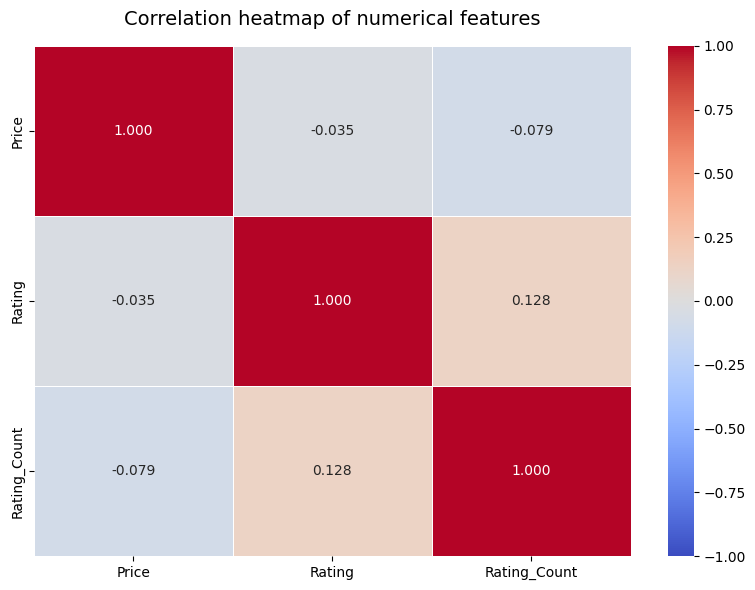

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation heatmap of numerical features", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

**Data Visualization**

In [30]:
sns.set_theme(style="whitegrid")

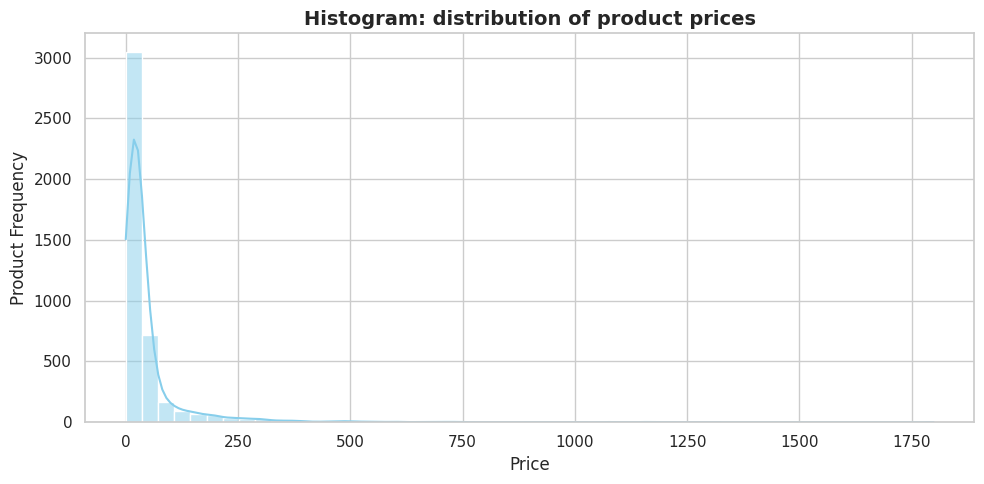

In [31]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Price"], bins=50, color="skyblue", kde=True)
plt.title("Histogram: distribution of product prices", fontsize=14, fontweight="bold")
plt.xlabel("Price", fontsize=12)
plt.ylabel("Product Frequency", fontsize=12)
plt.tight_layout()
plt.show()

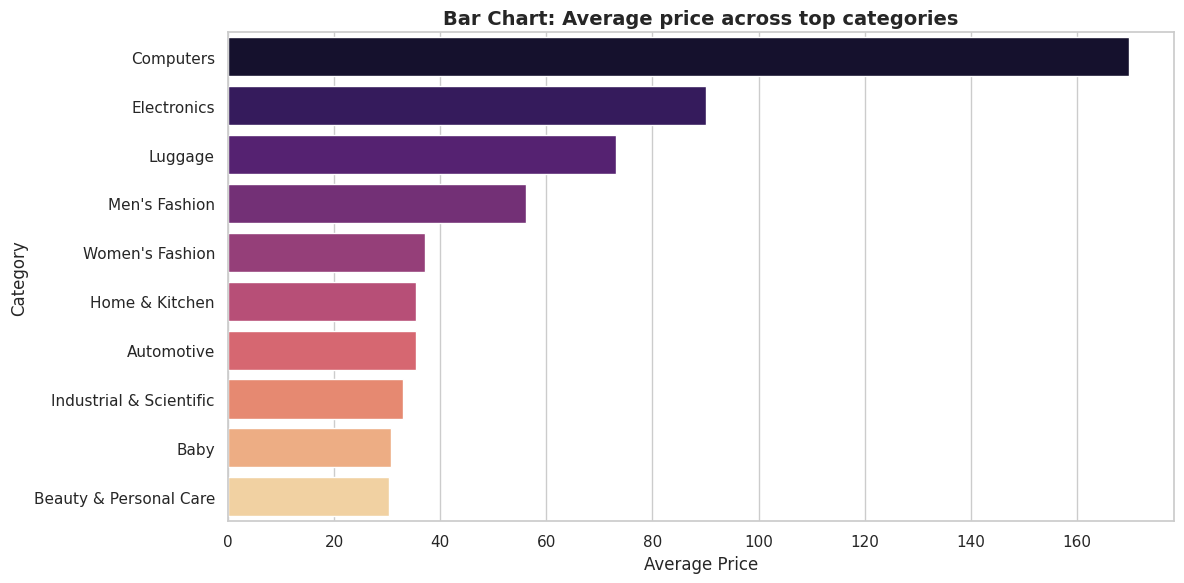

In [32]:
plt.figure(figsize=(12, 6))
avg_price_cat = df.groupby("Category")["Price"].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_price_cat.values, y=avg_price_cat.index, palette="magma", hue=avg_price_cat.index, legend=False)
plt.title("Bar Chart: Average price across top categories", fontsize=14, fontweight="bold")
plt.xlabel("Average Price", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.tight_layout()
plt.show()

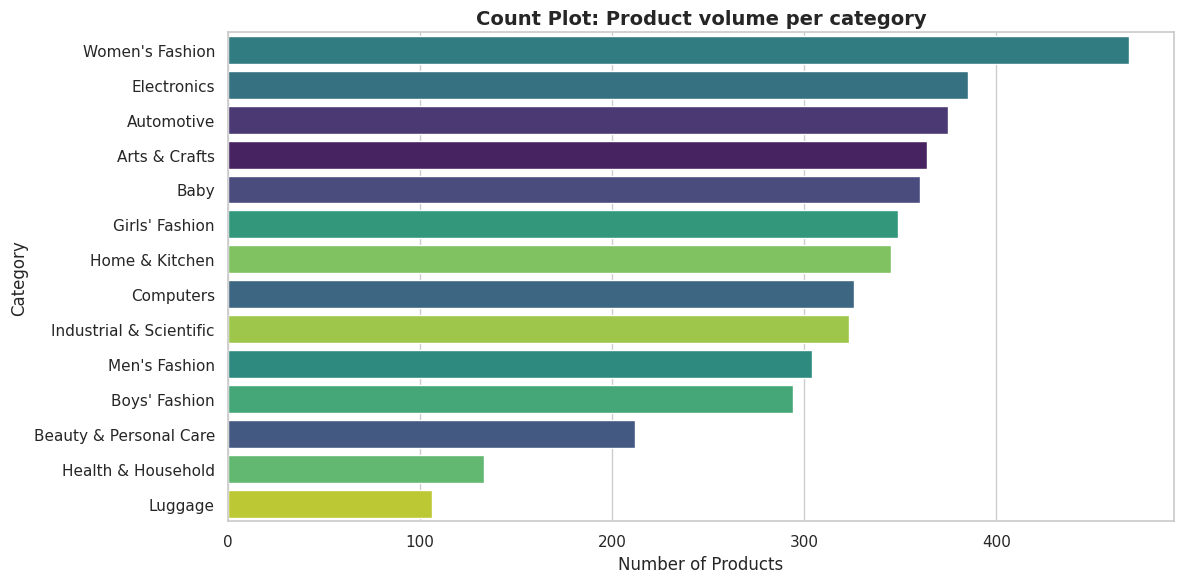

In [33]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y="Category", order=df["Category"].value_counts().index, palette="viridis", hue="Category", legend=False)
plt.title("Count Plot: Product volume per category", fontsize=14, fontweight="bold")
plt.xlabel("Number of Products", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.tight_layout()
plt.show()

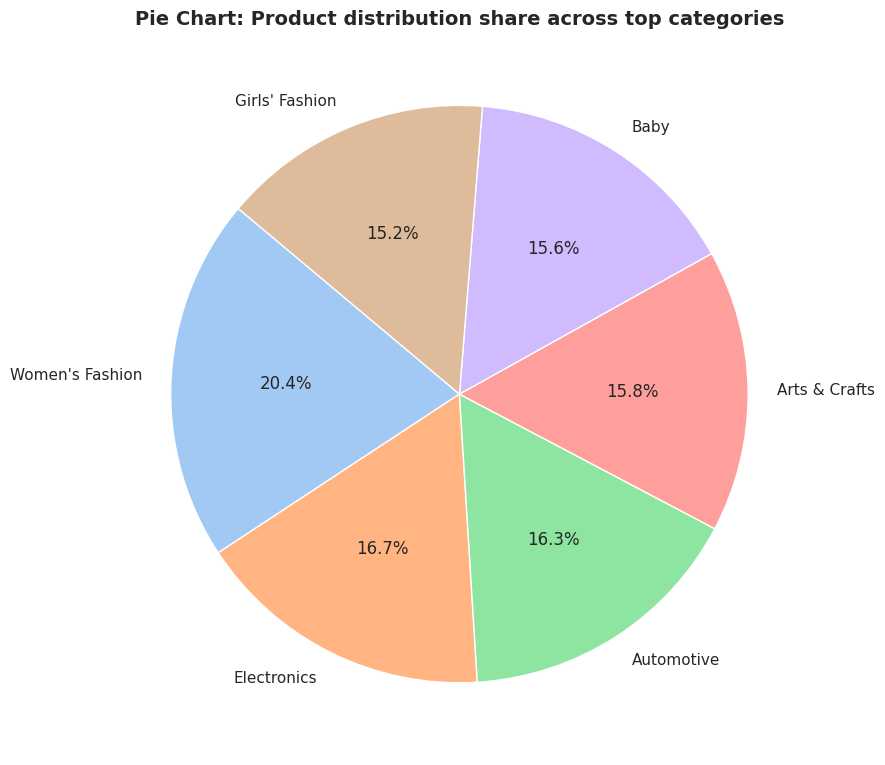

In [34]:
plt.figure(figsize=(9, 9))
cat_counts = df["Category"].value_counts().head(6)
plt.pie(cat_counts.values, labels=cat_counts.index, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("pastel"))
plt.title("Pie Chart: Product distribution share across top categories", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

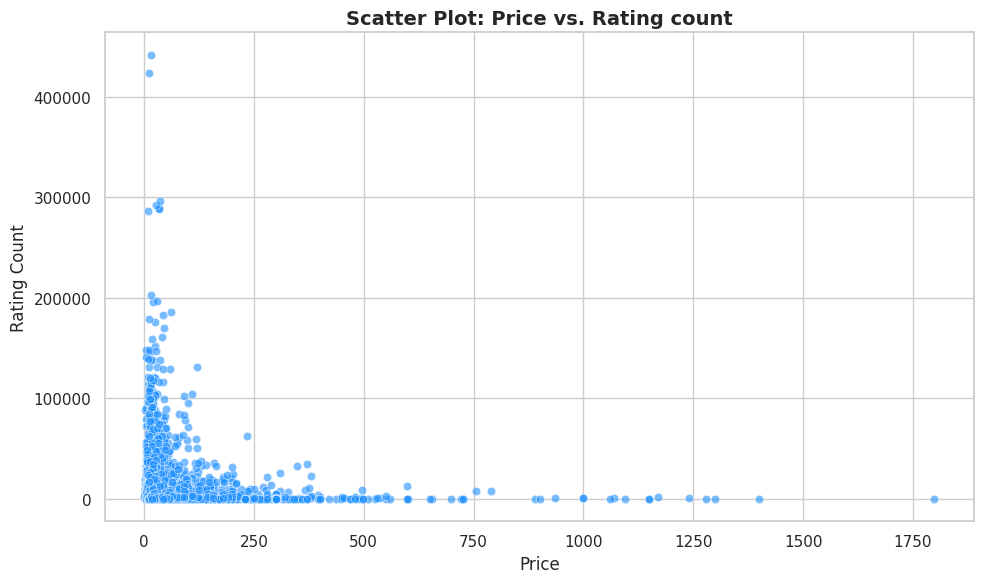

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Price", y="Rating_Count", alpha=0.6, color="dodgerblue")
plt.title("Scatter Plot: Price vs. Rating count", fontsize=14, fontweight="bold")
plt.xlabel("Price", fontsize=12)
plt.ylabel("Rating Count", fontsize=12)
plt.tight_layout()
plt.show()

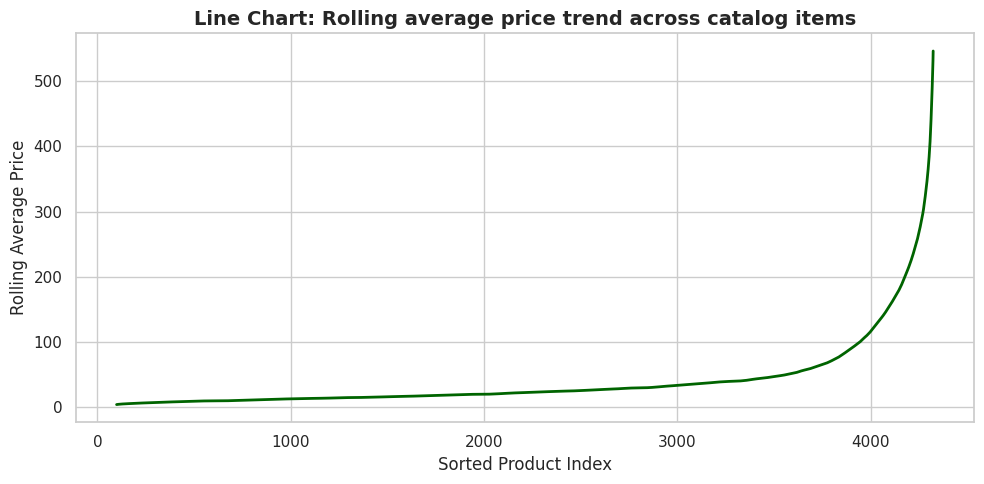

In [36]:
plt.figure(figsize=(10, 5))
sorted_df = df.sort_values(by="Price").reset_index(drop=True)
sorted_df["Rolling_Avg_Price"] = sorted_df["Price"].rolling(window=100).mean()
sns.lineplot(data=sorted_df, x=sorted_df.index, y="Rolling_Avg_Price", color="darkgreen", linewidth=2)
plt.title("Line Chart: Rolling average price trend across catalog items", fontsize=14, fontweight="bold")
plt.xlabel("Sorted Product Index", fontsize=12)
plt.ylabel("Rolling Average Price", fontsize=12)
plt.tight_layout()
plt.show()

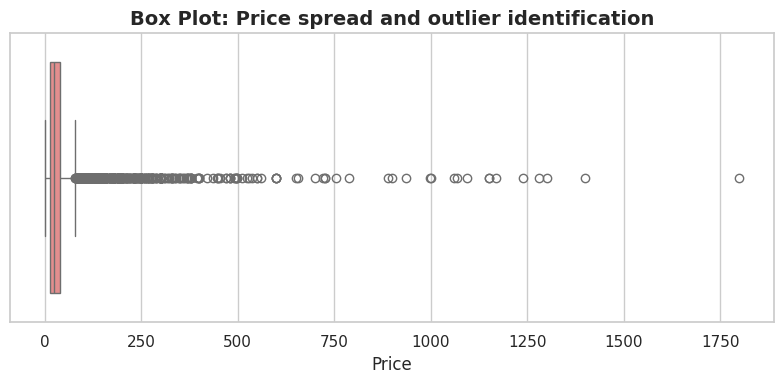

In [37]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Price"], color="lightcoral")
plt.title("Box Plot: Price spread and outlier identification", fontsize=14, fontweight="bold")
plt.xlabel("Price", fontsize=12)
plt.tight_layout()
plt.show()

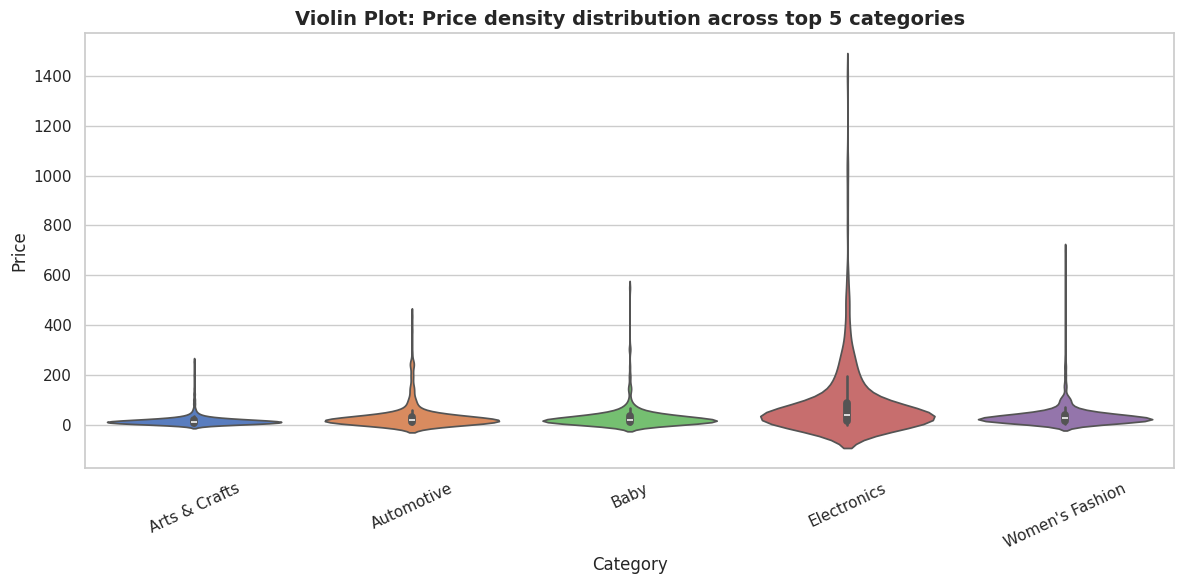

In [38]:
plt.figure(figsize=(12, 6))
top_cat_list = df["Category"].value_counts().head(5).index
filtered_df = df[df["Category"].isin(top_cat_list)]
sns.violinplot(data=filtered_df, x="Category", y="Price", palette="muted", hue="Category", legend=False)
plt.title("Violin Plot: Price density distribution across top 5 categories", fontsize=14, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

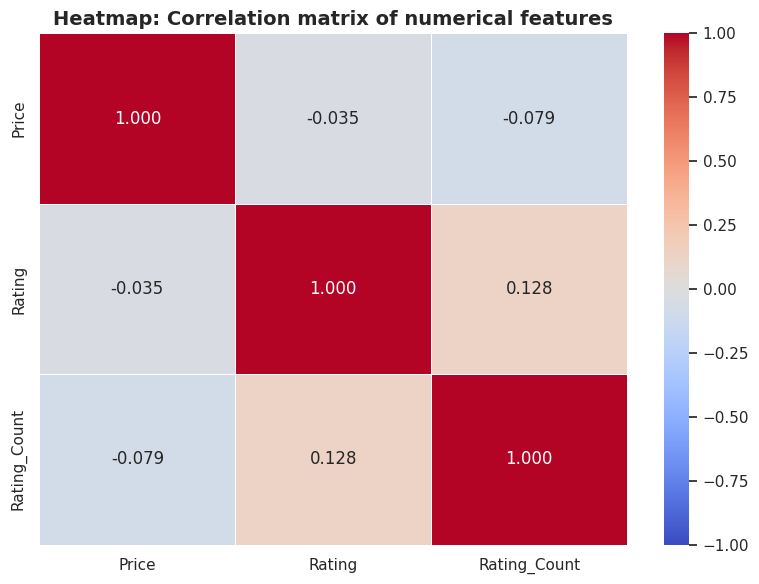

In [39]:
plt.figure(figsize=(8, 6))
corr_matrix = df[["Price", "Rating", "Rating_Count"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Heatmap: Correlation matrix of numerical features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

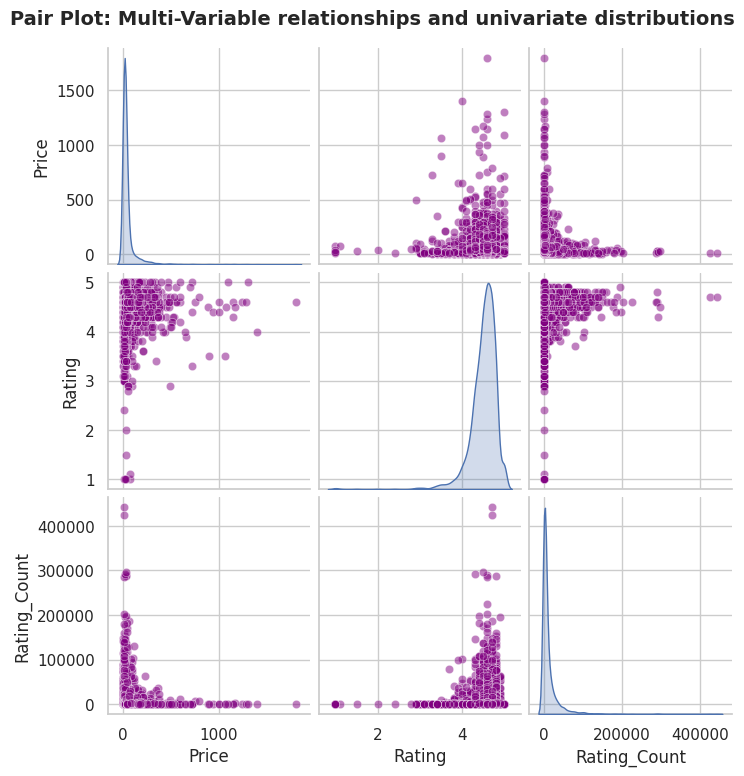

In [40]:
pairplot_fig = sns.pairplot(df[["Price", "Rating", "Rating_Count"]], diag_kind="kde", plot_kws={"alpha": 0.5, "color": "purple"})
pairplot_fig.fig.suptitle("Pair Plot: Multi-Variable relationships and univariate distributions", y=1.03, fontsize=14, fontweight="bold")
plt.show()

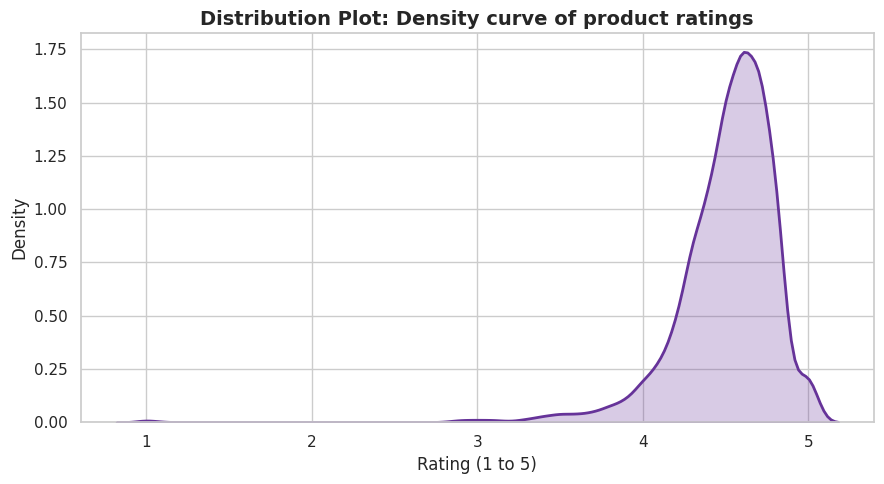

In [41]:
plt.figure(figsize=(9, 5))
sns.kdeplot(df["Rating"], fill=True, color="rebeccapurple", linewidth=2)
plt.title("Distribution Plot: Density curve of product ratings", fontsize=14, fontweight="bold")
plt.xlabel("Rating (1 to 5)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.tight_layout()
plt.show()

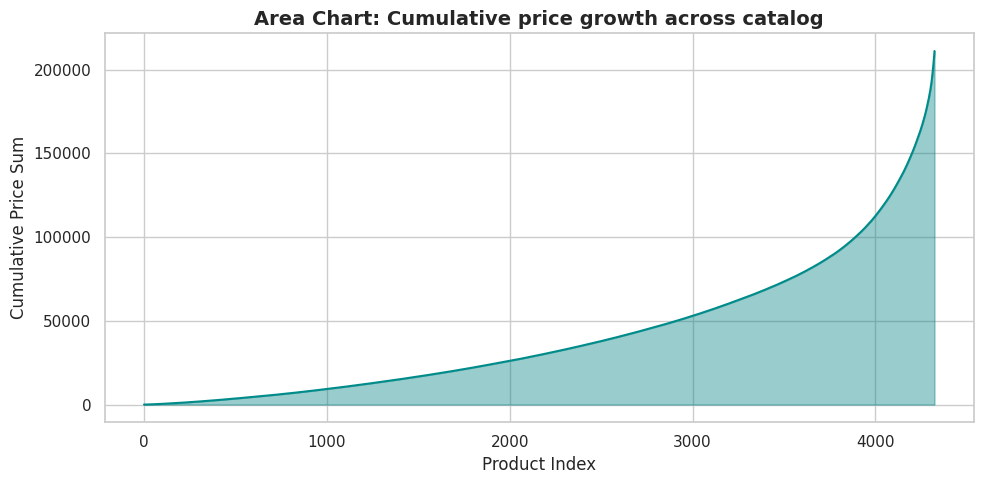

In [42]:
plt.figure(figsize=(10, 5))
cumulative_price = sorted_df["Price"].cumsum()
plt.fill_between(range(len(cumulative_price)), cumulative_price, color="teal", alpha=0.4)
plt.plot(cumulative_price, color="darkcyan", linewidth=1.5)
plt.title("Area Chart: Cumulative price growth across catalog", fontsize=14, fontweight="bold")
plt.xlabel("Product Index", fontsize=12)
plt.ylabel("Cumulative Price Sum", fontsize=12)
plt.tight_layout()
plt.show()